# CART MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid
from IPython.display import display
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

CART_OUTPUT_DIR = Path("../output/cart")
CART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_COMPARE_CSV = CART_OUTPUT_DIR / "cart_validation_comparison.csv"
TEST_COMPARE_CSV = CART_OUTPUT_DIR / "cart_test_comparison.csv"
CART_BUSINESS_SUMMARY_CSV = CART_OUTPUT_DIR / "cart_business_summary.csv"
FIXED_APPROVAL_COMPARE_CSV = CART_OUTPUT_DIR / "cart_business_fixed_approval_rate_comparison.csv"
FIXED_BAD_RATE_COMPARE_CSV = CART_OUTPUT_DIR / "cart_business_fixed_bad_rate_comparison.csv"
FIXED_BAD_RATE_SENSITIVITY_CSV = CART_OUTPUT_DIR / "cart_business_fixed_bad_rate_sensitivity.csv"
INCOME_MONOTONICITY_CHECK_CSV = CART_OUTPUT_DIR / "cart_income_monotonicity_check.csv"
AGE_MONOTONICITY_CHECK_CSV = CART_OUTPUT_DIR / "cart_age_monotonicity_check.csv"
BUREAU_YEAR_MONOTONICITY_CHECK_CSV = CART_OUTPUT_DIR / "cart_bureau_year_monotonicity_check.csv"


In [3]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

MEAN_CREDIT_AMOUNT = train_df['AMT_CREDIT'].mean()
print(f"Mean Credit Amount (Train): ${MEAN_CREDIT_AMOUNT:,.2f}")

TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"


Mean Credit Amount (Train): $599,184.06


In [4]:
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=False, dtype=int)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, drop_first=False, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=False, dtype=int)

X_train_ready = X_train_encoded.copy()
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train_ready), columns=X_train_ready.columns)
X_val_ready = pd.DataFrame(imputer.transform(X_val_ready), columns=X_val_ready.columns)
X_test_ready = pd.DataFrame(imputer.transform(X_test_ready), columns=X_test_ready.columns)


## EVALUATION METRICS

In [5]:
def compute_ks(y_true, y_score):
    df_ks = pd.DataFrame({"y_true": pd.Series(y_true).reset_index(drop=True), "y_score": pd.Series(y_score).reset_index(drop=True)})
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()
    if total_positives == 0 or total_negatives == 0: return np.nan
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives
    return np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

def evaluate_binary_model(model, X, y, split_name, model_name):
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "brier_score": brier_score_loss(y, y_proba),
        "ks_stat": compute_ks(y, y_proba)
    }

def evaluate_operating_point(y_true, y_score, approval_rate=None, bad_rate_target=None):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(y_score)
    sorted_y_true = y_true[order]
    sorted_y_score = y_score[order]
    n_obs = len(sorted_y_true)

    if approval_rate is not None and bad_rate_target is None:
        n_approve = int(np.floor(approval_rate * n_obs))
        n_approve = max(1, min(n_approve, n_obs))
    elif bad_rate_target is not None and approval_rate is None:
        cumulative_defaults = np.cumsum(sorted_y_true)
        candidate_counts = np.arange(1, n_obs + 1)
        cumulative_bad_rates = cumulative_defaults / candidate_counts
        feasible_counts = candidate_counts[cumulative_bad_rates <= bad_rate_target]
        if len(feasible_counts) == 0:
            n_approve = 1
        else:
            n_approve = int(feasible_counts[-1])
    else:
        raise ValueError("Set exactly one of approval_rate or bad_rate_target.")

    approved_y_true = sorted_y_true[:n_approve]
    approved_y_score = sorted_y_score[:n_approve]
    rejected_y_true = sorted_y_true[n_approve:]

    approved_defaults = int(approved_y_true.sum())
    approved_nondefaults = int(len(approved_y_true) - approved_defaults)
    rejected_defaults = int(rejected_y_true.sum())
    rejected_nondefaults = int(len(rejected_y_true) - rejected_defaults)
    
    observed_bad_rate_among_approved = approved_defaults / len(approved_y_true) if len(approved_y_true) else 0.0
    realized_approval_rate = len(approved_y_true) / n_obs
    approval_threshold = approved_y_score[-1] if len(approved_y_score) else 0.0

    return {
        "n_total_applicants": n_obs,
        "n_approved": len(approved_y_true),
        "n_rejected": len(rejected_y_true),
        "approval_rate": realized_approval_rate,
        "approved_defaults": approved_defaults,
        "approved_nondefaults": approved_nondefaults,
        "rejected_defaults": rejected_defaults,
        "rejected_nondefaults": rejected_nondefaults,
        "observed_bad_rate_among_approved": observed_bad_rate_among_approved,
        "approval_threshold": approval_threshold
    }

def plot_two_model_comparison(
    compare_df,
    value_col,
    title,
    x_label=None,
    as_percent=False,
    decimals=4
):
    plot_df = compare_df[["model_name", value_col]].copy()
    raw_values = plot_df[value_col].astype(float).to_numpy()
    display_values = raw_values * 100 if as_percent else raw_values
    model_names = plot_df["model_name"].tolist()
    y_pos = np.arange(len(plot_df))
    x_min = display_values.min()
    x_max = display_values.max()
    x_span = x_max - x_min
    padding = max(x_span * 0.35, 0.001 if not as_percent else 0.05)

    plt.figure(figsize=(8, 2.8))
    plt.plot(display_values, y_pos, linewidth=1, alpha=0.7)
    plt.scatter(display_values, y_pos, s=80)

    for x, y in zip(display_values, y_pos):
        label = f"{x:.{decimals}f}%" if as_percent else f"{x:.{decimals}f}"
        plt.text(x + padding * 0.05, y, label, va="center")

    plt.yticks(y_pos, model_names)
    plt.xlim(x_min - padding, x_max + padding)
    plt.xlabel(x_label if x_label is not None else value_col)
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

def plot_roc_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_true, y_proba):.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pr_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {average_precision_score(y_true, y_proba):.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## UNCONSTRAINED BASELINE

In [6]:
cart_baseline = DecisionTreeClassifier(
    max_depth=5,              
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)
cart_baseline.fit(X_train_ready, y_train)

baseline_val_prob = cart_baseline.predict_proba(X_val_ready)[:, 1]
baseline_val_result = evaluate_binary_model(cart_baseline, X_val_ready, y_val, "validation", "cart_unconstrained_baseline")


## UNCONSTRAINED TUNED

In [7]:
param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [100, 200, 500]
}

best_pr_auc = -1
best_cart_unconstrained = None

for params in ParameterGrid(param_grid):
    clf = DecisionTreeClassifier(**params, class_weight="balanced", random_state=42)
    clf.fit(X_train_ready, y_train)
    val_res = evaluate_binary_model(clf, X_val_ready, y_val, "validation", f"cart_unconstrained_d{params['max_depth']}_l{params['min_samples_leaf']}")
    if val_res['pr_auc'] > best_pr_auc:
        best_pr_auc = val_res['pr_auc']
        best_cart_unconstrained = clf

tuned_val_prob = best_cart_unconstrained.predict_proba(X_val_ready)[:, 1]
tuned_val_result = evaluate_binary_model(best_cart_unconstrained, X_val_ready, y_val, "validation", "cart_unconstrained_tuned")


## CONSTRAINED TUNED

In [8]:
original_feature_monotonicity = {
    "AMT_INCOME_TOTAL": -1,                 
    "DAYS_BIRTH": -1,                       
    "DAYS_EMPLOYED": -1,                    
    "AMT_REQ_CREDIT_BUREAU_HOUR": 1,        
    "AMT_REQ_CREDIT_BUREAU_DAY": 1,
    "AMT_REQ_CREDIT_BUREAU_WEEK": 1,
    "AMT_REQ_CREDIT_BUREAU_MON": 1,
    "AMT_REQ_CREDIT_BUREAU_QRT": 1,
    "AMT_REQ_CREDIT_BUREAU_YEAR": 1,
    "EXT_SOURCE_1": -1,                     
    "EXT_SOURCE_2": -1,                     
    "EXT_SOURCE_3": -1                      
}

mono_cst = []
for col in X_train_ready.columns:
    if col in original_feature_monotonicity:
        mono_cst.append(original_feature_monotonicity[col])
    else:
        mono_cst.append(0)

# We actively restrict the depth aggressively for scorecard emulation
param_grid_const = {
    'max_depth': [3, 4],
    'min_samples_leaf': [100, 200, 500]
}

best_pr_auc_c = -1
best_cart_constrained = None

for params in ParameterGrid(param_grid_const):
    clf = DecisionTreeClassifier(**params, monotonic_cst=mono_cst, class_weight="balanced", random_state=42)
    clf.fit(X_train_ready, y_train)
    val_res = evaluate_binary_model(clf, X_val_ready, y_val, "validation", f"cart_constrained_d{params['max_depth']}_l{params['min_samples_leaf']}")
    if val_res['pr_auc'] > best_pr_auc_c:
        best_pr_auc_c = val_res['pr_auc']
        best_cart_constrained = clf

constrained_val_prob = best_cart_constrained.predict_proba(X_val_ready)[:, 1]
constrained_val_result = evaluate_binary_model(best_cart_constrained, X_val_ready, y_val, "validation", "cart_constrained")


## VALIDATION COMPARISONS

Validation Metrics Comparison:


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
0,cart_unconstrained_baseline,validation,0.713720,0.180346,0.213573,0.316465
1,cart_unconstrained_tuned,validation,0.712659,0.197081,0.208153,0.322845
2,cart_constrained,validation,0.695032,0.163486,0.224290,0.289537


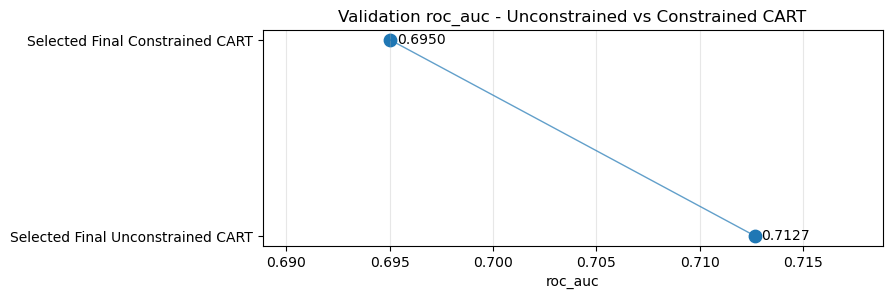

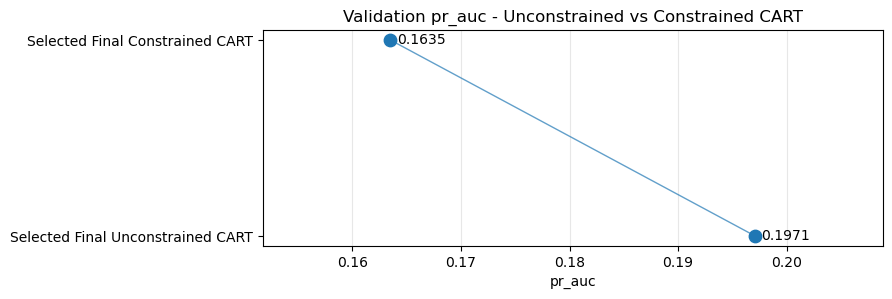

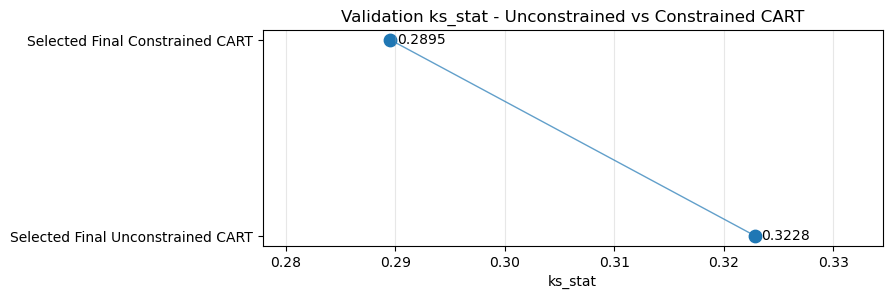

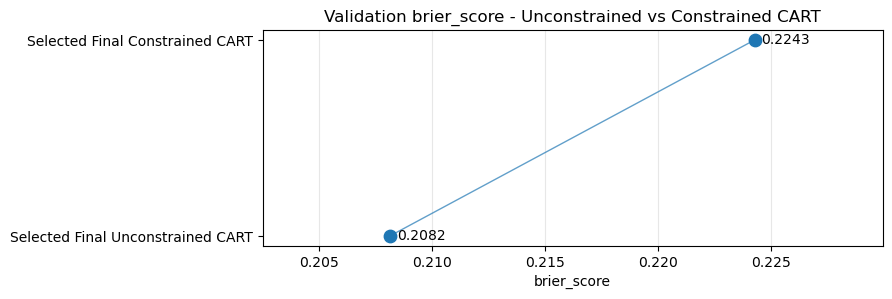

In [9]:
# Full Validation Metrics Table
full_val_compare_df = pd.DataFrame([baseline_val_result, tuned_val_result, constrained_val_result])
full_val_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
print("Validation Metrics Comparison:")
display(full_val_compare_df)

# Subset for Two-Model Plotting
val_compare_df = pd.DataFrame([tuned_val_result, constrained_val_result])
val_compare_df["model_name"] = ["Selected Final Unconstrained CART", "Selected Final Constrained CART"]

metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]
for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=val_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Unconstrained vs Constrained CART",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

## POST-TRAINING MONOTONICITY BEHAVIOR CHECKS

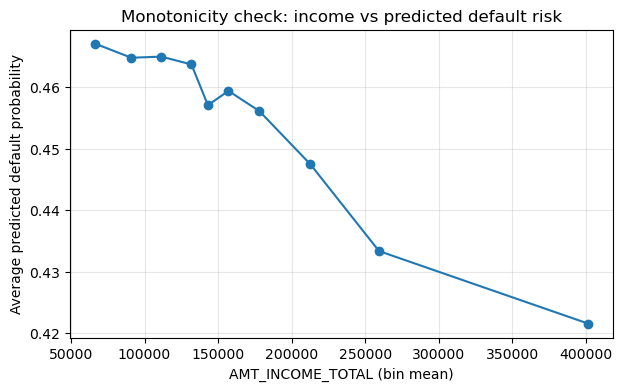

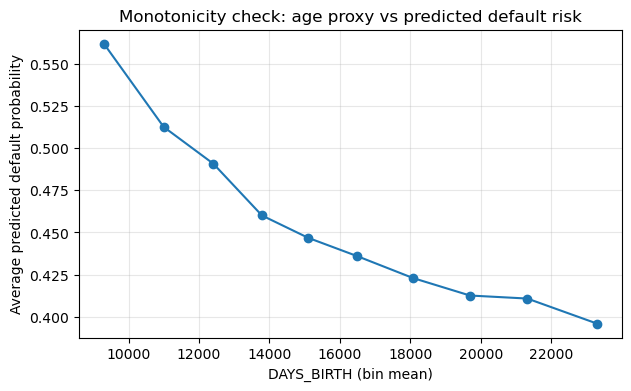

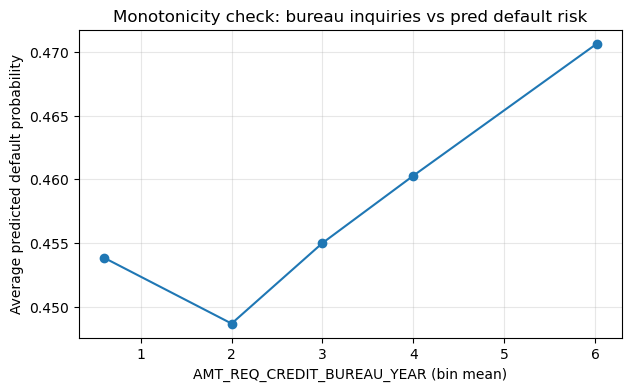

In [10]:
def monotonicity_check_table(model, X, feature_name, n_bins=10):
    check_df = pd.DataFrame({
        feature_name: X[feature_name],
        "pred_prob": model.predict_proba(X)[:, 1]
    }).copy()

    check_df["bin"] = pd.qcut(check_df[feature_name], q=n_bins, duplicates="drop")

    summary_df = (
        check_df
        .groupby("bin", observed=False)
        .agg(
            feature_mean=(feature_name, "mean"),
            avg_pred_prob=("pred_prob", "mean"),
            count=("pred_prob", "size")
        )
        .reset_index()
    )
    return summary_df

# Check and Save
income_monotonicity_df = monotonicity_check_table(best_cart_constrained, X_val_ready, "AMT_INCOME_TOTAL", n_bins=10)
age_monotonicity_df = monotonicity_check_table(best_cart_constrained, X_val_ready, "DAYS_BIRTH", n_bins=10)
bureau_year_monotonicity_df = monotonicity_check_table(best_cart_constrained, X_val_ready, "AMT_REQ_CREDIT_BUREAU_YEAR", n_bins=10)

income_monotonicity_df.to_csv(INCOME_MONOTONICITY_CHECK_CSV, index=False)
age_monotonicity_df.to_csv(AGE_MONOTONICITY_CHECK_CSV, index=False)
bureau_year_monotonicity_df.to_csv(BUREAU_YEAR_MONOTONICITY_CHECK_CSV, index=False)

# Plots
for df, title, xlabel in zip(
    [income_monotonicity_df, age_monotonicity_df, bureau_year_monotonicity_df],
    ["Monotonicity check: income vs predicted default risk", "Monotonicity check: age proxy vs predicted default risk", "Monotonicity check: bureau inquiries vs pred default risk"],
    ["AMT_INCOME_TOTAL (bin mean)", "DAYS_BIRTH (bin mean)", "AMT_REQ_CREDIT_BUREAU_YEAR (bin mean)"]
):
    plt.figure(figsize=(7, 4))
    plt.plot(df["feature_mean"], df["avg_pred_prob"], marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("Average predicted default probability")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


## BUSINESS VIEWS (TEST SET)

We project performance onto the isolated TEST set to interpret dollar amounts based on mean credit amounts.

In [11]:
baseline_test_prob = cart_baseline.predict_proba(X_test_ready)[:, 1]
tuned_test_prob = best_cart_unconstrained.predict_proba(X_test_ready)[:, 1]
constrained_test_prob = best_cart_constrained.predict_proba(X_test_ready)[:, 1]

baseline_test_result = evaluate_binary_model(cart_baseline, X_test_ready, y_test, "test", "cart_unconstrained_baseline")
tuned_test_result = evaluate_binary_model(best_cart_unconstrained, X_test_ready, y_test, "test", "cart_unconstrained_tuned")
constrained_test_result = evaluate_binary_model(best_cart_constrained, X_test_ready, y_test, "test", "cart_constrained")

test_compare_df = pd.DataFrame([baseline_test_result, tuned_test_result, constrained_test_result])
test_compare_df.to_csv(TEST_COMPARE_CSV, index=False)
print("Test Metrics Comparison:")
display(test_compare_df)

Test Metrics Comparison:


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
0,cart_unconstrained_baseline,test,0.711936,0.179767,0.212802,0.313015
1,cart_unconstrained_tuned,test,0.709535,0.187437,0.207107,0.322619
2,cart_constrained,test,0.700361,0.165448,0.222687,0.292474


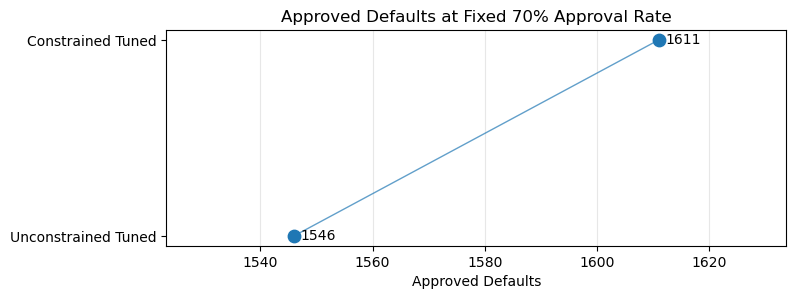

In [12]:
# Business View 1: Fixed Approval Rate
FIXED_APPROVAL_RATE = 0.70
tuned_fixed_approval = evaluate_operating_point(y_test, tuned_test_prob, approval_rate=FIXED_APPROVAL_RATE)
constrained_fixed_approval = evaluate_operating_point(y_test, constrained_test_prob, approval_rate=FIXED_APPROVAL_RATE)

fixed_approval_compare_df = pd.DataFrame([tuned_fixed_approval, constrained_fixed_approval])
fixed_approval_compare_df["model_name"] = ["Unconstrained Tuned", "Constrained Tuned"]

defaults_diff = constrained_fixed_approval["approved_defaults"] - tuned_fixed_approval["approved_defaults"]

plot_two_model_comparison(
    compare_df=fixed_approval_compare_df,
    value_col="approved_defaults",
    title="Approved Defaults at Fixed 70% Approval Rate",
    x_label="Approved Defaults",
    as_percent=False,
    decimals=0
)


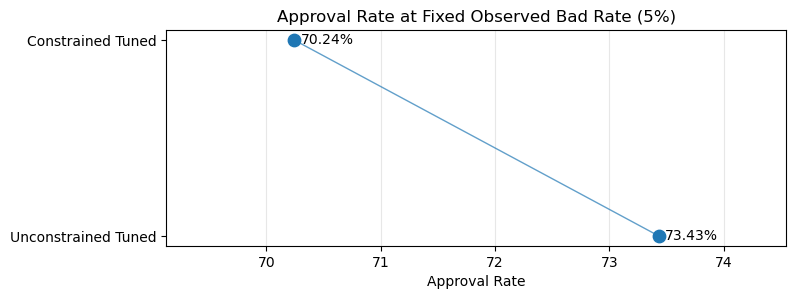

In [13]:
# Business View 2: Sensitivity Grid for Bad-Rate Targets
bad_rate_targets = [0.08, 0.06, 0.05, 0.04]
sensitivity_results = []

for target in bad_rate_targets:
    t_res = evaluate_operating_point(y_test, tuned_test_prob, bad_rate_target=target)
    c_res = evaluate_operating_point(y_test, constrained_test_prob, bad_rate_target=target)
    t_res["model_name"] = "Unconstrained Tuned"
    t_res["target_bad_rate"] = target
    c_res["model_name"] = "Constrained Tuned"
    c_res["target_bad_rate"] = target
    sensitivity_results.extend([t_res, c_res])

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.to_csv(FIXED_BAD_RATE_SENSITIVITY_CSV, index=False)

# Select headline target 5%
SELECTED_BAD_RATE_TARGET = 0.05
headline_df = sensitivity_df[sensitivity_df["target_bad_rate"] == SELECTED_BAD_RATE_TARGET].copy()

tuned_headline = headline_df[headline_df["model_name"] == "Unconstrained Tuned"].iloc[0]
constrained_headline = headline_df[headline_df["model_name"] == "Constrained Tuned"].iloc[0]
approved_applications_diff = tuned_headline["n_approved"] - constrained_headline["n_approved"]

plot_two_model_comparison(
    compare_df=headline_df,
    value_col="approval_rate",
    title=f"Approval Rate at Fixed Observed Bad Rate ({SELECTED_BAD_RATE_TARGET:.0%})",
    x_label="Approval Rate",
    as_percent=True,
    decimals=2
)


In [14]:
# Compact Business Delta
defaults_financial_impact = defaults_diff * MEAN_CREDIT_AMOUNT
opportunity_financial_impact = approved_applications_diff * MEAN_CREDIT_AMOUNT

biz_df = pd.DataFrame([
    {
        "scenario": f"Fixed {FIXED_APPROVAL_RATE*100:.0f}% approval rate",
        "unconstrained": tuned_fixed_approval["approved_defaults"],
        "constrained": constrained_fixed_approval["approved_defaults"],
        "gap (defaults/apps)": defaults_diff,
        "financial impact": f"${defaults_financial_impact / 1e6:,.2f} M",
        "interpretation": "Additional defaults admitted under constrained model (Loss)"
    },
    {
        "scenario": f"Fixed {SELECTED_BAD_RATE_TARGET*100:.0f}% bad-rate target",
        "unconstrained": tuned_headline["n_approved"],
        "constrained": constrained_headline["n_approved"],
        "gap (defaults/apps)": approved_applications_diff,
        "financial impact": f"${opportunity_financial_impact / 1e6:,.2f} M",
        "interpretation": "Additional applications rejected under constrained model (Opportunity Cost)"
    }
])
biz_df.to_csv(CART_BUSINESS_SUMMARY_CSV, index=False)
display(biz_df)


,scenario,unconstrained,constrained,gap (defaults/apps),financial impact,interpretation
0,Fixed 70% approval rate,1546,1611,65,$38.95 M,Additional defaults admitted under constrained...
1,Fixed 5% bad-rate target,33853,32382,1471,$881.40 M,Additional applications rejected under constra...
